# Attempt on 10s

Directories

In [68]:
from pathlib import Path

# Source folder: ~/Documents/vid_10s_dataset/
base_path = Path.home() / "Documents" / "vid_10s_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_10s_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_10s_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling"]

Splitting directories

In [5]:
from pathlib import Path
import shutil
import random
import os

# Source folder: ~/Documents/vid_10s_dataset/
base_path = Path.home() / "Documents" / "vid_10s_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_10s_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_10s_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling"]

# Train/Val ratio
train_ratio = 0.8

# Create output directories
for split_path in [train_path, val_path]:
    for cls in classes:
        os.makedirs(split_path / cls, exist_ok=True)

# Split and copy files
for cls in classes:
    class_dir = base_path / cls
    video_files = list(class_dir.glob("*.mp4"))
    random.shuffle(video_files)

    train_count = int(len(video_files) * train_ratio)
    train_videos = video_files[:train_count]
    val_videos = video_files[train_count:]

    for vid in train_videos:
        shutil.copy(vid, train_path / cls / vid.name)
    for vid in val_videos:
        shutil.copy(vid, val_path / cls / vid.name)

Model

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional
import tensorflow as tf

def build_cnn_lstm(input_shape=(300, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional
import tensorflow as tf

def build_cnn_lstm2(input_shape=(300, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),  # Intermediate temporal outputs
        Bidirectional(LSTM(64)),                         # Final temporal summary
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])
    return model


In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, AveragePooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional, AveragePooling2D
import tensorflow as tf

def build_cnn_lstm3(input_shape=(300, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, AveragePooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional, AveragePooling2D
import tensorflow as tf

img_size = 224

def build_cnn_lstm4(input_shape=(300, img_size, img_size, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model



Label

In [69]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

labels = ["starlight", "wave", "spectrum_cycling"]
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
y_cat = to_categorical(y_encoded)

Augmentation

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from pathlib import Path
import albumentations as A

img_size = 224

class OnTheFlyVideoGenerator(Sequence):
    def __init__(self, data_dir, class_names, frame_count=300, target_size=(img_size, img_size), batch_size=4, shuffle=True, augment=False):
        self.data_dir = Path(data_dir)
        self.class_names = class_names
        self.frame_count = frame_count
        self.target_size = target_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.video_paths = []
        self.labels = []
        self.augment = augment
        self.frame_aug = A.Compose([
            A.RandomBrightnessContrast(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.3),
            A.HueSaturationValue(p=0.4),
        ])

        for idx, class_name in enumerate(class_names):
            for video_file in (self.data_dir / class_name).glob("*.mp4"):
                self.video_paths.append(video_file)
                self.labels.append(idx)

        self.indices = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_x, batch_y = [], []
        for i in batch_indices:
            video_path = self.video_paths[i]
            frames = self.load_video_frames(video_path)
            batch_x.append(frames)
            batch_y.append(self.labels[i])
        return np.array(batch_x), tf.keras.utils.to_categorical(batch_y, num_classes=len(self.class_names))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while len(frames) < self.frame_count and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, self.target_size)
            if self.augment:
                frame = self.frame_aug(image=frame)["image"]
            frame = frame / 255.0
            frames.append(frame)
        cap.release()
        if len(frames) < self.frame_count:
            pad_frame = np.zeros((self.target_size[1], self.target_size[0], 3))
            frames += [pad_frame] * (self.frame_count - len(frames))
        elif len(frames) > self.frame_count:
            frames = frames[:self.frame_count]  # Trim if needed
        return np.array(frames)


In [71]:
class_names = ["starlight", "wave", "spectrum_cycling"]

train_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_dataset" / "split" / "train",
    class_names=class_names,
    augment=True
)

val_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_dataset" / "split" / "val",
    class_names=class_names,
    augment=False
)

Train

In [72]:
import tensorflow as tf
from sklearn.utils import class_weight
import os
import json
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# model = build_cnn_lstm()
# model = build_conv_lstm()
# model = build_cnn_lstm2()
# model = build_cnn_lstm3()
model = build_cnn_lstm4()

base_path = Path.cwd().resolve().parents[1]
checkpoint_path = base_path / "models" / "checkpoints" / "video_try_model.h5"
final_model_path = base_path / "models" / "video_recognition" / "video_model8.h5"
metrics_path = base_path / "metrics" / "video_recognition"
metrics_path.mkdir(parents=True, exist_ok=True) 

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compute class weights from train_gen
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.labels),
    y=train_gen.labels
)
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping]
)

# === Evaluate Best Model ===
best_refined_model = tf.keras.models.load_model(checkpoint_path)
val_loss, val_accuracy = best_refined_model.evaluate(val_gen)
print(f"Best Validation Loss: {val_loss:.4f}")
print(f"Best Validation Accuracy: {val_accuracy:.4f}")

# === Save Final Model and Metrics ===
best_refined_model.save(final_model_path)
with open(metrics_path / "video_model8.json", "w") as f:
    json.dump(history.history, f)

Epoch 1/10


ResourceExhaustedError: Graph execution error:

Detected at node 'sequential/time_distributed/conv2d/Relu' defined at (most recent call last):
    File "c:\Anaconda3\envs\tf\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Anaconda3\envs\tf\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "c:\Anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Anaconda3\envs\tf\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Anaconda3\envs\tf\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Anaconda3\envs\tf\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "c:\Anaconda3\envs\tf\lib\asyncio\base_events.py", line 603, in run_forever
      self._run_once()
    File "

Evaluation

In [3]:
test_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_dataset" / "split" / "test",
    class_names=["starlight", "wave", "spectrum_cycling"],
    shuffle=False  # disable shuffling so predictions align with files
)

In [72]:
from tensorflow.keras.models import load_model

all_preds = []
all_labels = []

base_path = Path.cwd().resolve().parents[1]
model_path = base_path / "models" / "video_recognition" / "video_model7.h5"
model = load_model(model_path)

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    batch_preds = model.predict(x_batch)
    all_preds.extend(batch_preds.argmax(axis=1))
    all_labels.extend(y_batch.argmax(axis=1))

1/1 [==============================] - 3s 3s/step


In [73]:
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nDetailed Report:\n", classification_report(all_labels, all_preds, target_names=test_gen.class_names))


Test Accuracy: 0.7333333333333333

Detailed Report:
                   precision    recall  f1-score   support

       starlight       1.00      1.00      1.00         5
            wave       1.00      0.20      0.33         5
spectrum_cycling       0.56      1.00      0.71         5

        accuracy                           0.73        15
       macro avg       0.85      0.73      0.68        15
    weighted avg       0.85      0.73      0.68        15



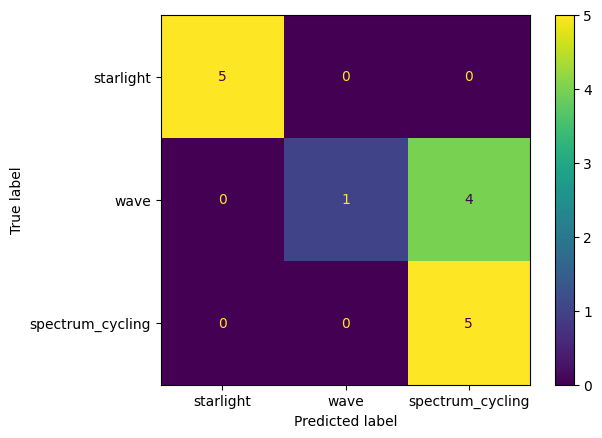

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=test_gen.class_names).plot()

In [127]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.sysconfig.get_build_info()["cuda_version"])
print("Built with cuDNN:", tf.sysconfig.get_build_info()["cudnn_version"])

TensorFlow version: 2.10.1
Built with CUDA: 64_112
Built with cuDNN: 64_8


Inference

Input shape: (300, 112, 112, 3)
1/1 [==============================] - 1s 1s/step
testt_16.mp4 → [0.90099245 0.05528859 0.04371898]
Class Probabilities:
starlight: 0.9010
wave: 0.0553
spectrum_cycling: 0.0437
Predicted Class: starlight


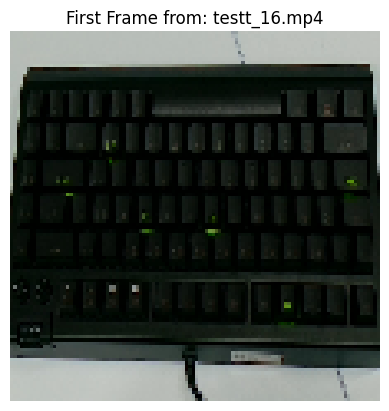

In [ ]:
import numpy as np
from pathlib import Path
from tensorflow.keras.models import load_model

base_path = Path.cwd().resolve().parents[1]
model_path = base_path / "models" / "video_recognition" / "video_model6.h5"
model = load_model(model_path)

# Robot/pictures/testt_1.mp4
# "C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\testt_16.mp4"
# Robot/pictures/MicrosoftTeams-video (4).mp4
# C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\MicrosoftTeams-video (1).mp4
path = Path(r"C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\testt_16.mp4")

# Load and preprocess frames
frames = test_gen.load_video_frames(path)
print("Input shape:", frames.shape)  # Debug

# Expand dims for batch
input_tensor = np.expand_dims(frames, axis=0)  # (1, frames, img_size, img_size, 3)

# Predict
pred_probs = model.predict(input_tensor)[0]

# Output
print(f"{path.name} → {pred_probs}")
print("Class Probabilities:")
for i, prob in enumerate(pred_probs):
    print(f"{test_gen.class_names[i]}: {prob:.4f}")

print(f"Predicted Class: {test_gen.class_names[np.argmax(pred_probs)]}")

import matplotlib.pyplot as plt

first_frame = frames[0]  # Shape: (img_size, img_size, 3)

plt.imshow(first_frame)
plt.title(f"First Frame from: {path.name}")
plt.axis('off')
plt.show()